In [84]:
import numpy as np #Linear Algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sklearn


In [85]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tahirmohd/network-ad")

print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, 'Social_Network_Ads.csv'))
df.sample(5)

Using Colab cache for faster access to the 'network-ad' dataset.
Path to dataset files: /kaggle/input/network-ad


,Age,EstimatedSalary,Purchased
366,58,47000,1
209,46,22000,0
241,38,59000,0
170,21,88000,0
350,38,113000,1


# Train Test Split

In [86]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop("Purchased",axis=1), df['Purchased'], test_size=0.3, random_state=0)

X_train.shape, X_test.shape

((280, 2), (120, 2))

# StandardScaler

We use transform() only on X_train
Why?

Because the test set is supposed to represent unseen data.

If you calculate the mean/std from the test set, you're allowing information from the test data to influence preprocessing. This is a form of data leakage.



In [87]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters(Like mean and S.D)
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [88]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

## Convert scaled NumPy arrays back into Pandas DataFrames and putting the original column names back.

In [89]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

## Now, compare Mean and S.D for data BEFORE and AFTER Scaling

In [90]:
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [91]:
np.round(X_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


## After Scaling Mean becomes 0, and S.D becomes 1

# Effect of Scaling
## The Graph will be as it is, but you can notice changes in Axis Scale Values

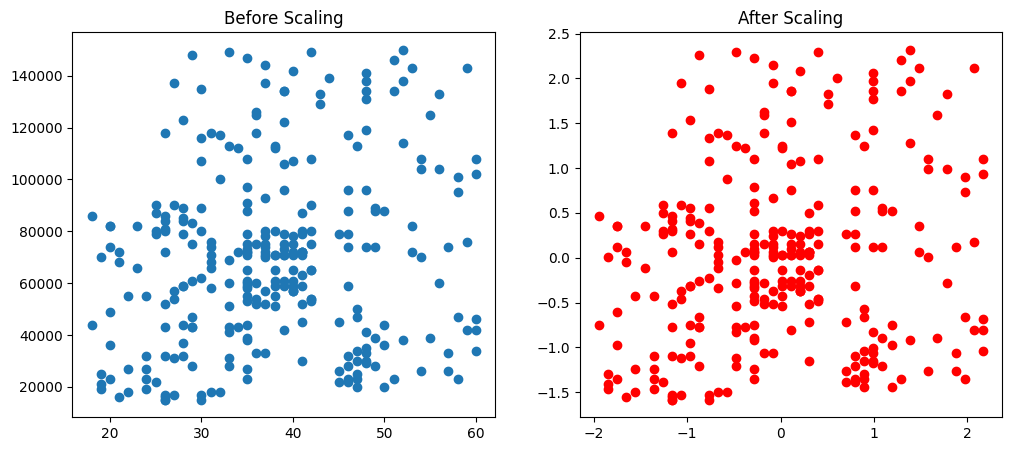

In [92]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'],X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'],X_train_scaled['EstimatedSalary'], color='red')
ax2.set_title("After Scaling")
plt.show()


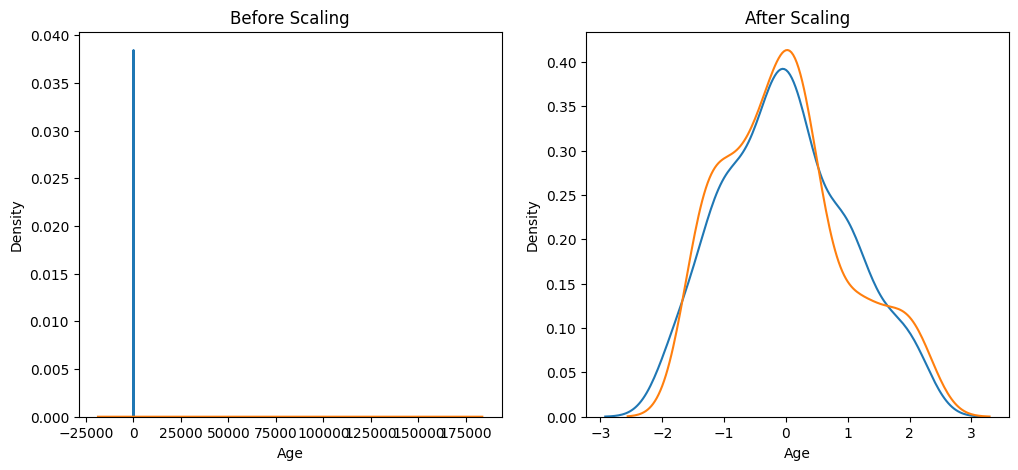

In [93]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12,5))

# before scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)

# after scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax = ax2)

plt.show()

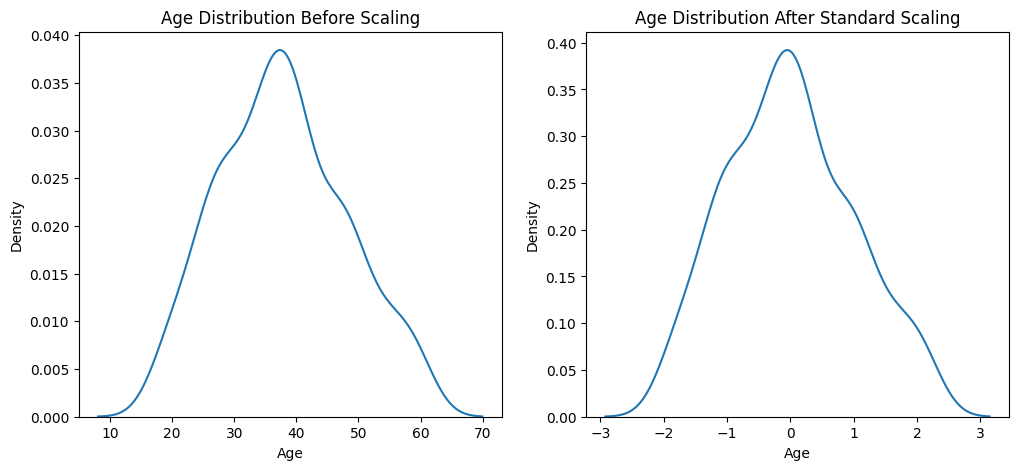

In [94]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)

# after scaling
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)

plt.show()

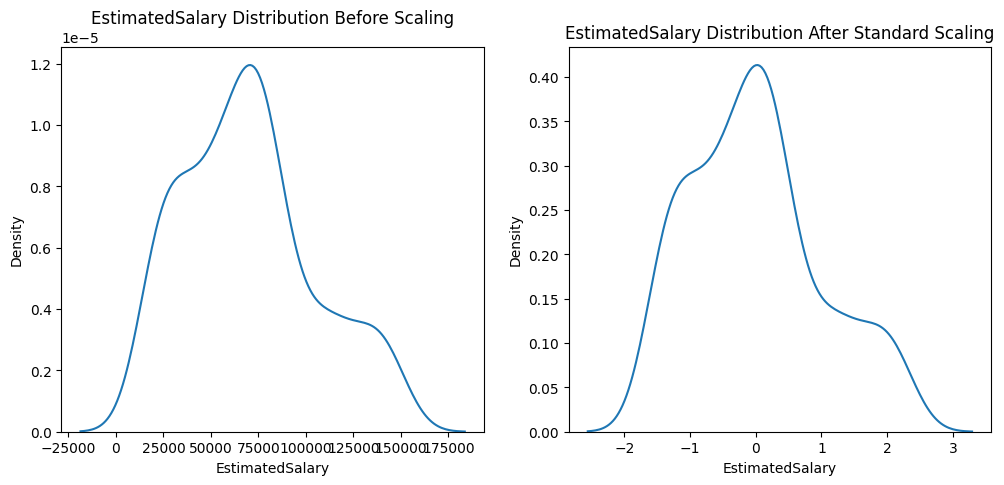

In [95]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('EstimatedSalary Distribution Before Scaling')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('EstimatedSalary Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)

plt.show()

# Why scaling is important?

## For Logistic Regression Standardization can be helpfull

In [96]:
from sklearn.linear_model import LogisticRegression

In [97]:
lr = LogisticRegression(random_state=0)
lr_scaled= LogisticRegression(random_state=0)

In [98]:
lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled,y_train)

LogisticRegression(random_state=0)

In [99]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [100]:
from sklearn.metrics import accuracy_score

## In Logistic Regression the score for Scaled data increased compared to Normal Data

In [101]:
print("Actual", accuracy_score(y_test,y_pred))
print("Scaled", accuracy_score(y_test,y_pred_scaled))

Actual 0.875
Scaled 0.8666666666666667


## For Decision Tree Standardization might not be usefull because Scaled data gives less accuracy result

In [102]:
from sklearn.tree import DecisionTreeClassifier

In [103]:
dt = DecisionTreeClassifier(random_state=0)
dt_scaled = DecisionTreeClassifier(random_state=0)

In [104]:
dt.fit(X_train,y_train)
dt_scaled.fit(X_train_scaled,y_train)

DecisionTreeClassifier(random_state=0)

In [105]:
y_pred = dt.predict(X_test)
y_pred_scaled = dt.predict(X_test_scaled)

In [106]:
from sklearn.metrics import accuracy_score

In [107]:
print("Actual", accuracy_score(y_test,y_pred))
print("Scaled", accuracy_score(y_test,y_pred_scaled))

Actual 0.875
Scaled 0.6583333333333333
